In [1]:
# ML Models --->
# (1). Supervised ML Models ---> In this , we will trained our labelled data .
# (a). Discrete ---> LogisticRegression , Decisiontreeclassifier , Randomforestclassifier , naive bayes.
# (b). Continuous ---> LinearRegression , D.T. Regressor , R.F. Regressor
# (2). UNSUPERVISED ML Models ---> In this , we will trained our unlabelled data .
# KMeans , PCA , Apriori .

# (1). Supervised ML Models --->
# (a). LinearRegression


# workflow ---->
# data ingestion  --->>>data cleaning and  preprocessing ---->>>>>> select  ml  model  based  on  target  column ----->>>>
# model training ------->>>model prediction------->>>>>model evaluation 

import os  
os.getcwd()

import numpy as np 
import  pandas  as pd  
df =  pd.read_csv('C:\\Users\\HP\\ml  batch -p\\ml  models\\insurance - insurance.csv')
df.head()

x = df.drop(columns=['charges'])
y = df['charges']

from  sklearn.preprocessing  import LabelEncoder 
le  =  LabelEncoder()
x['sex'] = le.fit_transform(x['sex'])
x['smoker'] = le.fit_transform(x['smoker'])
x['region'] =  le.fit_transform(x['region'])





In [2]:
from  sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.linear_model import  LinearRegression 
lr  =  LinearRegression()

In [3]:
lr.fit(x_train , y_train)

y_pred = lr.predict(x_test)

from  sklearn.metrics import  r2_score 
r2_score(y_pred,y_test)

0.7086166433516325

In [7]:
import os  
os.getcwd()

'C:\\Users\\HP\\ml  batch -p'

In [9]:
# apply  linear regresssion   on churn modeling  ------>>>>>>target  column is estimatedsalary

import  numpy as np 
import  pandas as pd  

df = pd.read_csv('C:\\Users\\HP\\ml  batch -p\\Churn_Modelling - Churn_Modelling.csv')
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

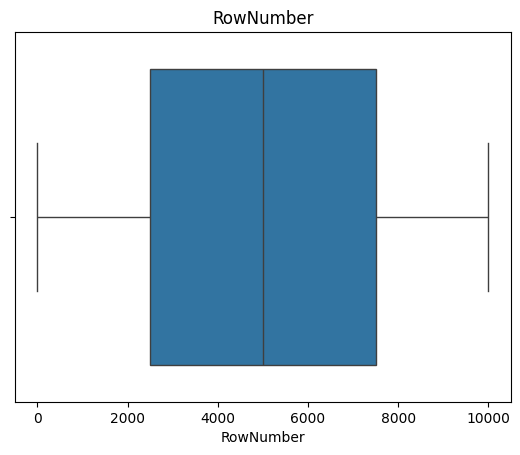

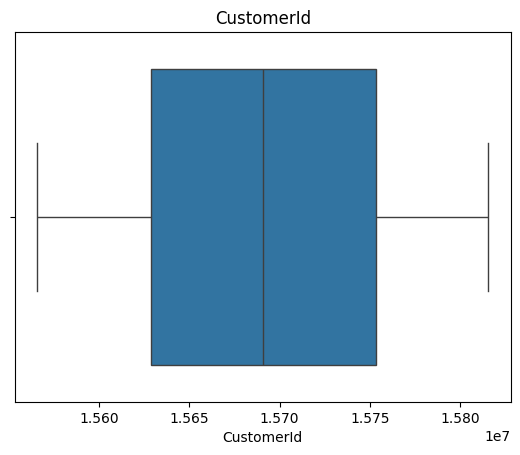

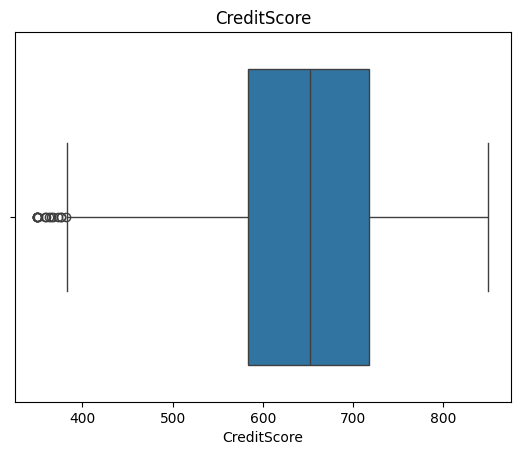

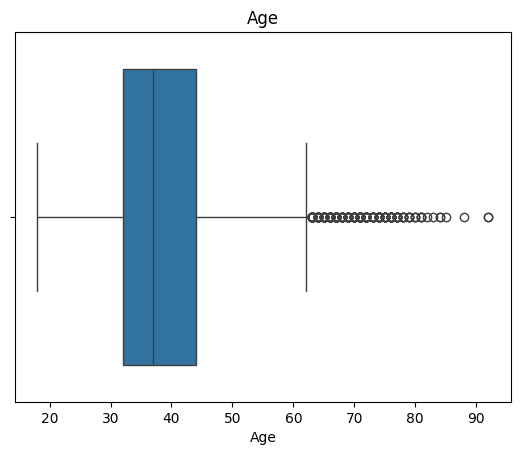

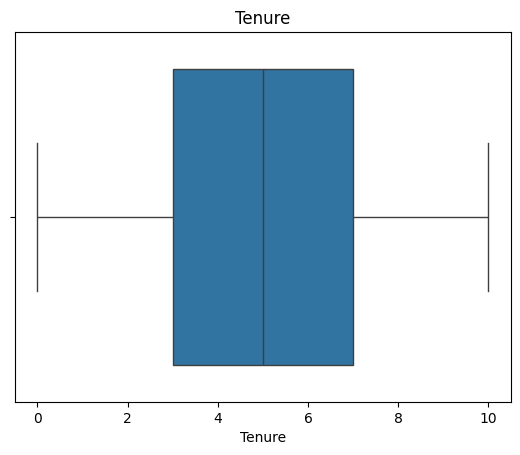

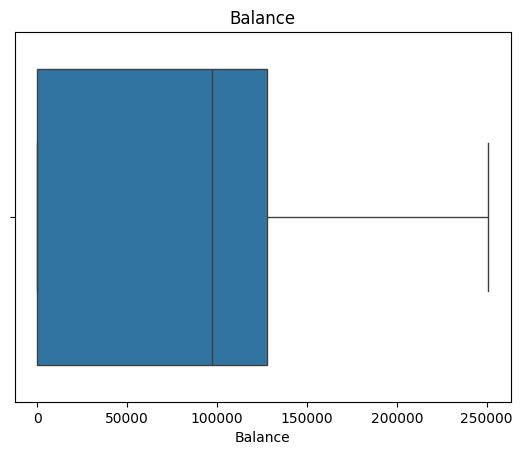

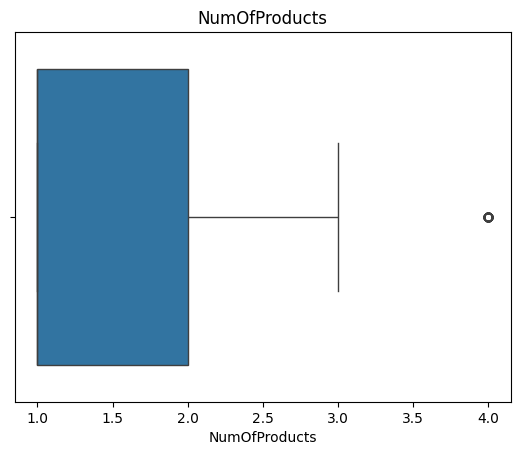

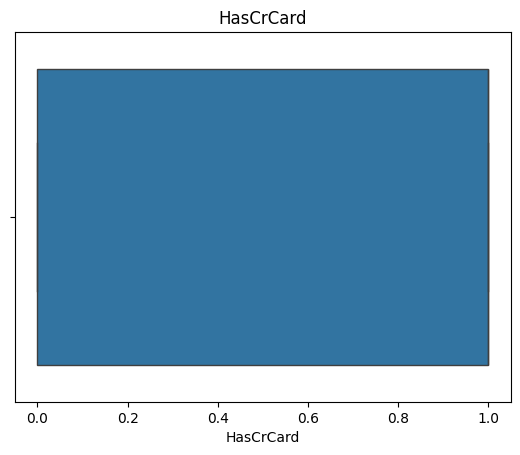

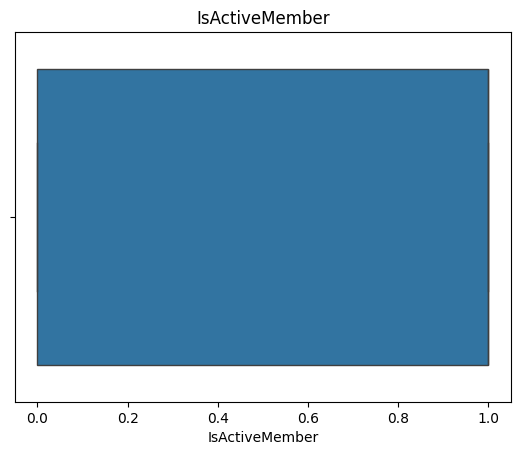

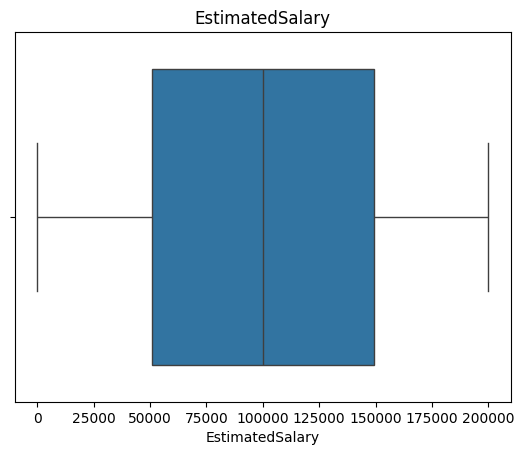

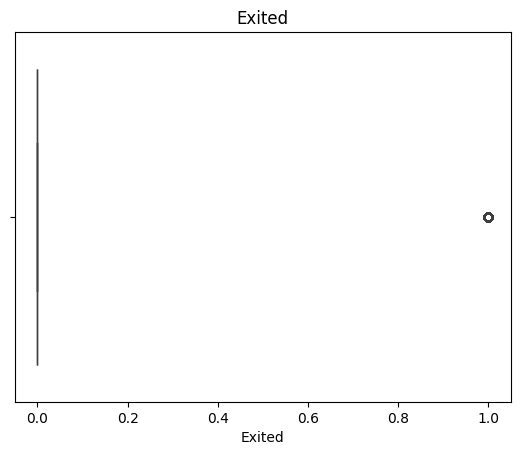

In [11]:
# outlier check :-
import  seaborn  as  sns 
import matplotlib.pyplot as plt
num1 = df.select_dtypes(include=['number']).columns.to_list()
cols = df[num1].columns.to_list()

for  i in cols :
    plt.figure()
    sns.boxplot(x=df[i])
    plt.title(i)

outlier  = ['CreditScore','Age','NumOfProducts']

per_25 =  df[outlier].quantile(0.25)
per_75  =  df[outlier].quantile(0.75)

IQR = per_75 - per_25

upper_limit = per_75 + 1.5*IQR
lower_limit =  per_25 - 1.5*IQR

df[outlier] = df[outlier].clip(lower=lower_limit, upper=upper_limit, axis=1)



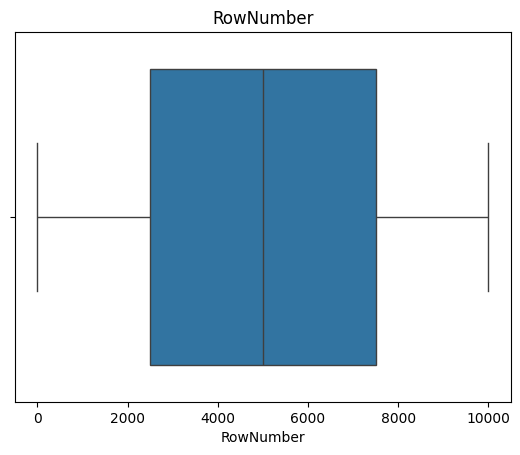

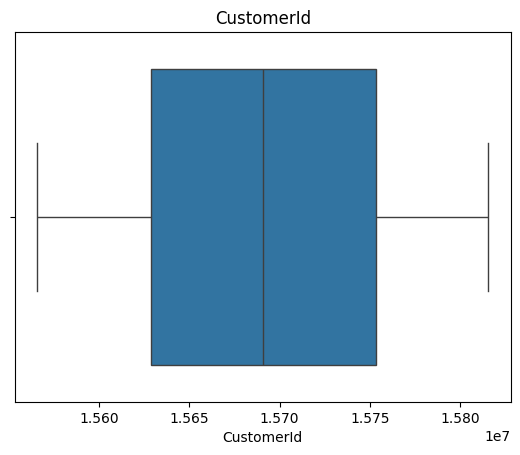

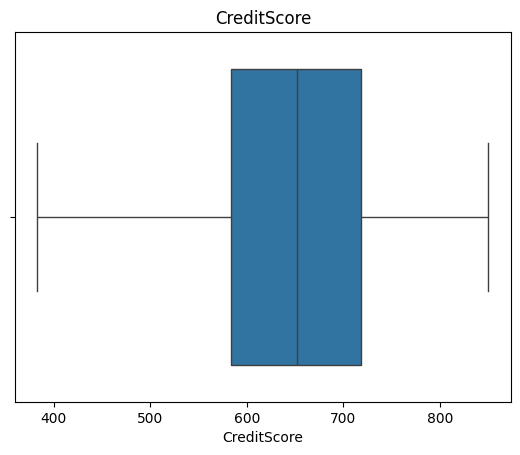

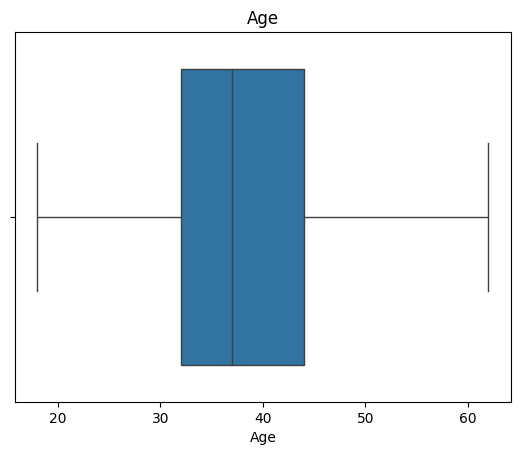

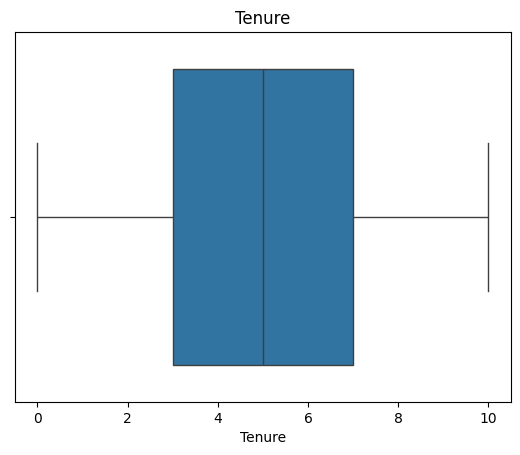

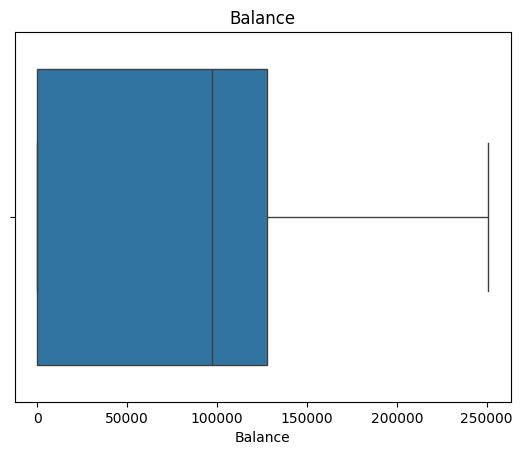

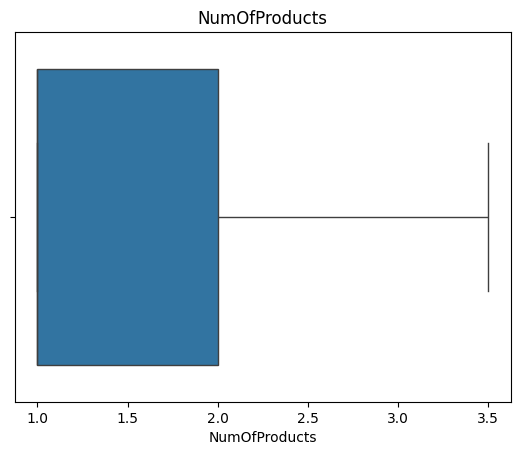

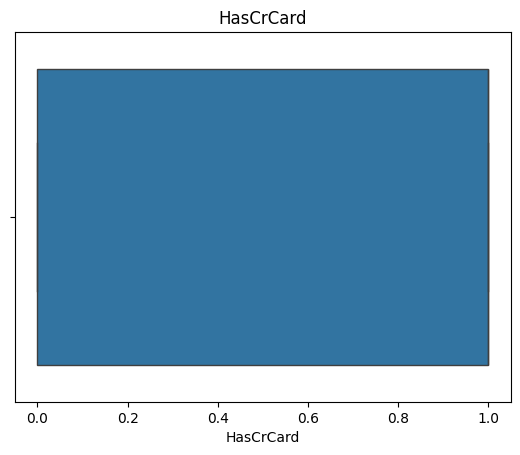

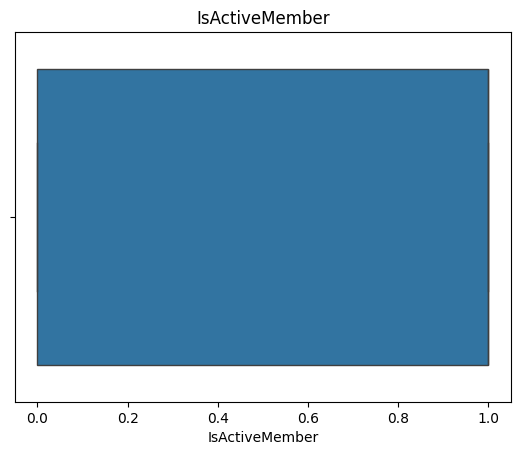

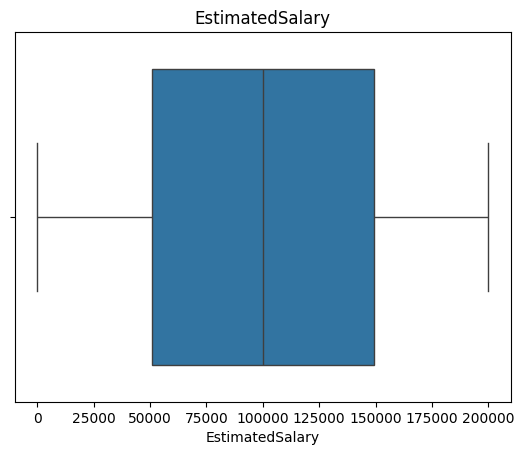

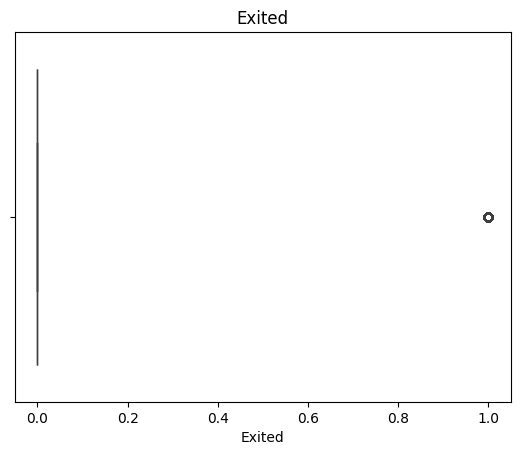

In [12]:
for  i in cols :
    plt.figure()
    sns.boxplot(x=df[i])
    plt.title(i)

In [13]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [14]:
x = df.drop(columns=['Surname','RowNumber','CustomerId','EstimatedSalary'])
y = df['EstimatedSalary']

from  sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
9254,686,France,Male,32,6,0.00,2.0,1,1,0
1561,632,Germany,Male,42,4,119624.60,2.0,1,1,0
1670,559,Spain,Male,24,3,114739.92,1.0,1,0,1
6087,561,France,Female,27,9,135637.00,1.0,1,0,1
6669,517,France,Male,56,9,142147.32,1.0,0,0,1


In [15]:
from sklearn.preprocessing  import OneHotEncoder

ohe = OneHotEncoder(drop='first',sparse_output = False,dtype = np.int32)

cat  =  x_train.select_dtypes(include=['object','category']).columns.to_list()
num =  x_train.select_dtypes(include=['number']).columns.to_list()

encoded = ohe.fit_transform(x_train[cat])
encoded1 = ohe.transform(x_test[cat])
encoded_pd =  pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cat),index = x_train.index)
encoded1_pd =  pd.DataFrame(encoded1,columns=ohe.get_feature_names_out(cat),index = x_test.index)


In [16]:
from  sklearn.preprocessing  import  StandardScaler
sc=  StandardScaler()
x_train_sc =  sc.fit_transform(x_train[num])
x_test_sc =  sc.transform(x_test[num])

In [17]:
x_train_new =  pd.DataFrame(x_train_sc,columns=x_train[num].columns, index=x_train.index )

# columns=x_train[num].columns      “These values belong to Age, Balance, CreditScore”
# index=x_train.index                 “Row 23 here is the SAME customer as row 23 there”

x_test_new  =  pd.DataFrame(x_test_sc,columns=x_test[num].columns, index=x_test.index )



x_train =  pd.concat([x_train_new,encoded_pd],axis=1)
x_test =  pd.concat([x_test_new,encoded1_pd],axis=1)

In [18]:
np.round(x_train.describe(),2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,Geography_Germany,Geography_Spain,Gender_Male
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.25,0.25,0.55
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.43,0.43,0.50
min,-2.79,-2.11,-1.74,-1.22,-0.93,-1.54,-1.03,-0.51,0.00,0.00,0.00
25%,-0.69,-0.68,-0.70,-1.22,-0.93,-1.54,-1.03,-0.51,0.00,0.00,0.00
50%,0.01,-0.17,-0.00,0.33,-0.93,0.65,0.97,-0.51,0.00,0.00,1.00
75%,0.70,0.55,0.69,0.82,0.83,0.65,0.97,-0.51,1.00,0.00,1.00
max,2.06,2.39,1.73,2.80,3.47,0.65,0.97,1.97,1.00,1.00,1.00


In [19]:
x_train.isnull().sum()

CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
Exited               0
Geography_Germany    0
Geography_Spain      0
Gender_Male          0
dtype: int64

In [20]:
from  sklearn.linear_model  import  LinearRegression  
lr = LinearRegression()
lr =  lr.fit(x_train,y_train)

In [24]:
y_pred =  lr.predict(x_test)

In [25]:
from  sklearn.metrics  import r2_score 
r2_score(y_test,y_pred)


-0.00368461589311897

In [54]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
df = pd.read_csv(r"C:\Users\Admin\ml  models - p\Churn_Modelling - Churn_Modelling.csv")
X = df.drop(columns=["EstimatedSalary", "RowNumber", "CustomerId", "Surname"])
y = df["EstimatedSalary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", LinearRegression())
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))

# there is  no  relation  between  estimated salary and  age  and  other columns  


R2: -0.0037019460577378815
RMSE: 57562.78603461825
